In [635]:
import fluid_flow_1d_lofi as lofi
import fluid_flow_1d_hifi_eval as hifi
import matplotlib.pyplot as plt
import importlib

In [636]:
# u_timeseries_lofi = lofi.TimeSeries(f"{lofi.root_path}/../../data/velocity_timeseries_lofi_1d")
# u_timeseries_midfi = lofi.TimeSeries(f"{lofi.root_path}/../../data/velocity_timeseries_midfi_1d")
# u_l = lofi.Function(lofi.U)
# u_m = lofi.Function(lofi.U)
# u_timeseries_lofi.retrieve(u_l.vector(), 0.01)
# u_timeseries_midfi.retrieve(u_m.vector(), 0.01)
# plt.plot(u_l.vector()[:])
# plt.plot(u_m.vector()[:])


In [637]:
# kt_lofi_fn = lofi.state_solve(k0, return_type="function")
# k0_fn = lofi.interpolate(lofi.Expression("10*pow(x[0],2)*pow(0.1*x[0]-1,2)", degree=2), lofi.K)
# plt.plot(kt_hifi)
# lofi.assemble(kt_hifi_fn.dx(0) * lofi.TestFunction(lofi.K) * lofi.dx)[:]

In [649]:
# k0_a = lofi.interpolate(lofi.Expression("pow(x[0], 2)", degree=1), lofi.K).vector()[:]
# k0 = lofi.interpolate(lofi.Expression("1-4*pow(x[0] - 0.5, 2)", degree=2), lofi.K).vector()[:]
# k0 = lofi.interpolate(lofi.Expression("pow(x[0], 3)-1.5*pow(x[0], 2)+0.5", degree=2), lofi.K).vector()[:]
k0 = lofi.interpolate(lofi.Expression("10*pow(x[0],2)*pow(x[0]-1,2)", degree=2), lofi.K).vector()[:]
# k0_guess = lofi.interpolate(lofi.Expression("2*(0.4 < x[0] && x[0] < 0.6)", degree=1), lofi.K).vector()[:]
# k0 = k0_guess
# k0 = hifi.interpolate(hifi.Expression("x[0]*(1-x[0])*(9-10*x[0])", degree=1), hifi.C).vector()[:]
kt_in = lofi.interpolate(lofi.Expression("pow(x[0], 3)", degree=2), lofi.K).vector()[:]
k0_in = lofi.interpolate(lofi.Expression("pow(x[0], 4)", degree=2), lofi.K).vector()[:]

In [640]:
k0_1 = lofi.interpolate(lofi.Expression("5*pow(x[0],2)*pow(x[0]-1,2)", degree=2), lofi.K).vector()[:]
k0_2 = lofi.interpolate(lofi.Expression("pow(x[0], 3)-1.5*pow(x[0], 2)+0.5", degree=2), lofi.K).vector()[:]


In [650]:
importlib.reload(lofi)
# importlib.reload(lofi_copy)
importlib.reload(hifi)

Succesfully imported fluid_flow_1d_lofi


<module 'fluid_flow_1d_hifi_eval' from '/Users/mmadhav/GitRepos/sabl/examples/Transient_Fluid_Flow_Tracer_1D/python/serverside/fluid_flow_1d_hifi_eval.py'>

In [651]:
kt_1_lofi = lofi.state_solve(k0_1, return_type="vector", annotate=False, return_all=True)
kt_1_hifi = hifi.state_solve(k0_1, return_type="vector", return_all=True)
disc_1 = kt_1_hifi - kt_1_lofi;

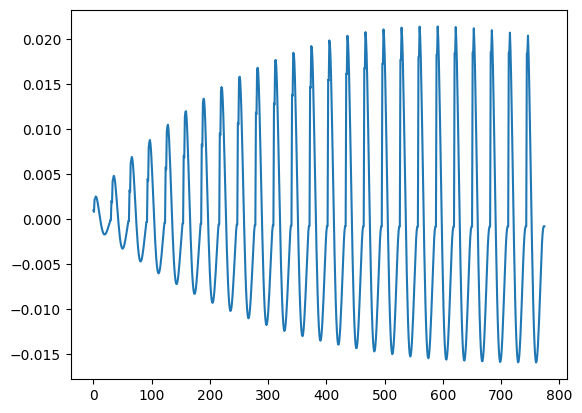

In [652]:
plt.plot(disc_1)

In [644]:
kt_2_lofi = lofi.state_solve(2*k0_1, return_type="vector", annotate=False, return_all=True)
kt_2_hifi = hifi.state_solve(2*k0_1, return_type="vector", return_all=True)
disc_2 = kt_2_hifi - kt_2_lofi;

In [646]:
print(lofi.np.linalg.norm(disc_2 - 2*disc_1)/lofi.np.linalg.norm(disc_2))

0.00866908949068444


In [633]:
kt_lofi = lofi.state_solve(k0, return_type="vector", annotate=False, return_all=True)
# kt_lofi_copy = lofi_copy.state_solve(k0, return_type="vector", annotate=False, return_all=True)
kt_hifi = hifi.state_solve(k0, return_type="vector", return_all=True)
discrep_kt = kt_hifi - kt_lofi

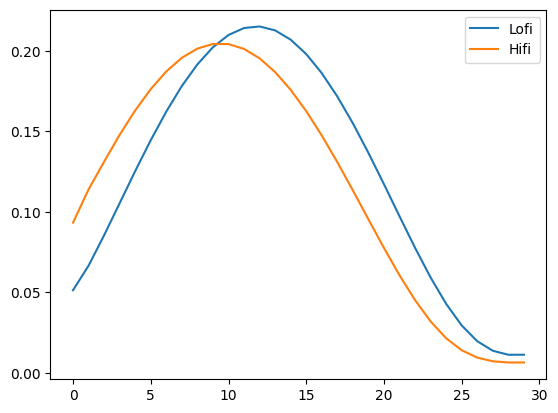

In [634]:
# plt.plot(kt_lofi[:30], label="Lofi")
# # plt.plot(kt_hifi[:30], label="Hifi")
# plt.legend()
plt.plot(kt_lofi[-30:], label="Lofi")
plt.plot(kt_hifi[-30:], label="Hifi")
plt.legend()

In [617]:
lofi.np.linalg.norm(kt_lofi[-30:]-kt_hifi[-30:])/lofi.np.linalg.norm(kt_lofi[-30:])

0.0011941292266739007

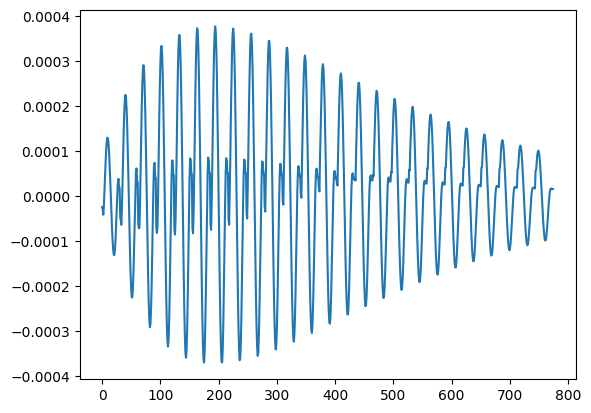

In [618]:
plt.plot(discrep_kt)

In [70]:
# Test if "important" four functions are working.
# print(lofi.apply_solution_operator_z_jacobian_transpose(kt_in_long, k0))
# print(lofi.misfit_gradient(kt_k0, k0))
# kt_in_long = lofi.np.repeat(kt_in, 25)
# print(lofi.apply_misfit_hessian(kt_in_long, k0, kt_k0).shape)
# print(lofi.apply_rs_hessian(k0_in, k0))

(775,)


In [125]:
# Hessian Finite Difference Check
hess_exact = lofi.apply_rs_hessian(k0_in, k0).flatten()
norm_hess_exact = lofi.np.linalg.norm(hess_exact)
dJ = lambda m: lofi.J_hat_np(m)*0 + lofi.J_hat_np.derivative(forget=None)
epsilon=0.1
hess_fd = (dJ(k0 + epsilon * k0_in) - dJ(k0 - epsilon * k0_in)) / (2 * epsilon)

print("Hessian Relative Diff: ", lofi.np.linalg.norm(hess_fd - hess_exact)/norm_hess_exact)

Hessian Relative Diff:  1.8171551589284304e-14


In [3]:
# Low-Fidelity Optimization Test 
k0_guess = lofi.fenics_convert(k0, "function", lofi.K);
k_n = lofi.state_solve(k0_guess, return_type = "function", plot_k=False, verbose=False, annotate=True);

# Set up inverse problem
J_inv = lofi.J(k0_guess, k_n)
control = lofi.Control(k0_guess)
J_hat = lofi.ReducedFunctional(J_inv, control)

# Solve Inverse Problem
with lofi.stop_verbose():
    k0_opt_lofi = lofi.minimize(J_hat, method="Newton-CG", callback=lofi.callback_call(J_hat), tol=1e-3, options={"disp": True})


Iteration  Objective Value      Gradient Norm  
---------------------------------------------
1          0.008899             0.001426       
2          0.000820             0.000074       
3          0.000759             0.000003       
4          0.000759             0.000000       
5          0.000759             0.000000       
Optimization terminated successfully.
         Current function value: 0.000759
         Iterations: 5
         Function evaluations: 5
         Gradient evaluations: 5
         Hessian evaluations: 25


In [6]:
# kt_lofi = lofi.state_solve(k0, "vector");
# u_end_lofi = lofi.Function(lofi.U)
# lofi.u_timeseries.retrieve(u_end_lofi.vector(), 0.1)
# print(u_end_lofi.vector()[:])
# plt.plot(u_end_lofi.vector()[:])


# kt_midfi = lofi.state_solve(k0, "vector");
# u_end_midfi = lofi.Function(lofi.U)
# lofi.u_timeseries.retrieve(u_end_midfi.vector(), 0.1)
# print(u_end_midfi.vector()[:])
# plt.plot(u_end_midfi.vector()[:])

In [8]:
# plt.plot(disc_k0_1)
# plt.plot(disc_k0_2)